# Simulation validation: Simulation of the drain templates

The goal of this notebook is to validate our simulator by reproducing, through simulation, the results from Montagne, Ginès, Fujii and Rondelez in the paper *"Boosting functionality of synthetic DNA circuits
with tailored deactivation"*, Nature Communications, 2016.

In this article, the authors introduce the concept of the drain template (or inactivation process) in PEN-DNA systems. This notebook explores the influence of various parameters on a system composed of a signal, its autocatalytic template, and a drain template.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Set the font to Arial 
plt.rcParams['font.family'] = 'Arial'

# Get the absolute path to the root directory
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)


from PEN_simulation import PEN_System
from strands import Signal, Drain, Template


# Saving figs
saving=True
if saving:
    os.makedirs("figures/drains", exist_ok=True)



def create_system(alpha_concentration=0, 
                  template_concentration=10, 
                  template_moins=1,
                  drain_concentration=0, 
                  drain_sequence="AAAACTCGTCAGAATG",
                  drain_plus=None,
                  temperature=45,
                  leak=6.3e-7, 
                  ):
    """Create a system with a signal, its autocatalytic converter template and a drain template"""

    # Create a signal
    alpha = Signal(name="alpha", 
                   sequence="CATTCTGACGAG", 
                   concentration=alpha_concentration, 
                   protected=False, 
                   IsDrained=True
                   )
    
    if drain_plus:
        drain_sequence=drain_plus*'T'+"CTCGTCAGAATG"
    # Create a drain
    drain = Drain(name="drain", 
                  input=alpha, 
                  concentration=drain_concentration, 
                  sequence=drain_sequence, 
                  protected=True)
    
    if template_moins > 0:
        template_sequence = 'CTCGTCAGAATGCTCGTCAGAATG'[:-template_moins]
    else:
        template_sequence = 'CTCGTCAGAATGCTCGTCAGAATG'

    # Create a template
    template = Template(name="aT_alpha", 
                        sequence=template_sequence,
                        input=alpha, 
                        output=alpha, 
                        concentration=template_concentration, 
                        nick="BsmI", 
                        protected=True, 
                        irreversible=False,
                        phosphorylated=True
                        )
    
    # Create a system
    system = PEN_System(temperature=temperature)
    system.add_signal(alpha)
    system.add_drain(drain)
    system.add_template(template)

    # Enzymes concentration of the article
    system.concentration_pol=8
    system.concentration_BsmI=400
    system.concentration_exo=25

    # Add a leak rate for the polymerase
    system.leak=leak
    
    return system


def compute_Ct(system,y,t):
    """ Compute the time at which the concentration of the signal is 20% of its maximal value"""
    conc=system.concentration_list(y,"alpha")
    conc_20 = 0.2 * conc[-1]

    # We don't want to compute a Ct if the final concentration is close to 0
    if conc_20 < 1:
        return 0
    
    # Binary search for c such that conc[c] = conc_20
    # This is the first index where conc[c] > conc_20
    b=len(conc)-1
    a=1
    while a<b :
        c=(a+b)//2
        if conc[c]<conc_20:
            a=c+1
        else:
            b=c
    return t[a]

## A first example of use: A signal alpha and its autocatalytic template

PEN System Summary
Temperature: 45 °C
Leak rate: 6.3e-07
Sodium concentration: 0.07 M
Magnesium concentration: 0.0125 M

--------------------------------------------------
Enzyme Concentrations:
  Nb.BsmI concentration: 400 U/µL
  Nt.BstNBI concentration: None U/µL
  Polymerase concentration: 8 U/µL
  Exonuclease concentration: 25 nM


--------------------------------------------------
Kinetic Rates Dictionary
--------------------------------------------------
alpha           <-> aT_alpha        (input) : k_on = 5.92e-01 nM⁻¹·min⁻¹, k_off = 3.39e+02 min⁻¹
alpha           <-> aT_alpha        (output) : k_on = 4.23e-01 nM⁻¹·min⁻¹, k_off = 7.12e+01 min⁻¹
alpha           <-> drain           : k_on = 4.23e-01 nM⁻¹·min⁻¹, k_off = 7.12e+01 min⁻¹
drain           <-> alpha_drained   : k_on = 4.35e-01 nM⁻¹·min⁻¹, k_off = 3.39e-01 min⁻¹
--------------------------------------------------
aT_alpha        : rate = 3.61e-02

--------------------------------------------------
List of Signals
---------

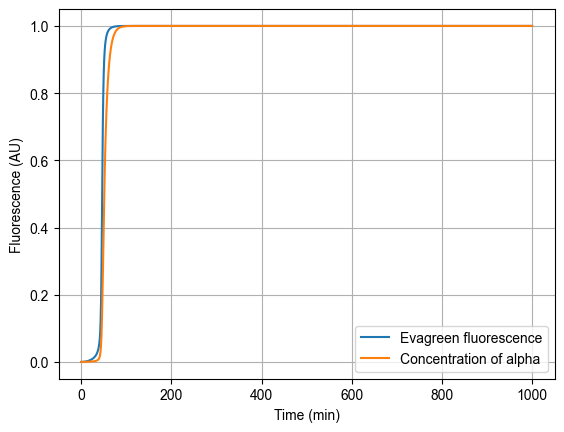

In [2]:
# Definition of the PEN_System
syst=create_system(
    alpha_concentration=0,
    template_moins=1,
    template_concentration=50,
    drain_plus=None,
    drain_concentration=10,
    temperature=45,
    leak=6.3e-7, 
)

# Define the time in minutes
t = np.linspace(0, 1000, 1001) #1000 minutes

# Simulate the system
y = syst.solve_system(t)

# Summary of the system
syst.print(detailed_kinetics=True, enzymes_kinetic=True)

# Plot the system
alpha_concentrations=syst.concentration_list(y,"alpha", option="alone") # extract the solution corresponding to alpha
eva=syst.concentration_list(y,"Evagreen") # extract the solution corresponding to the Evagreen fluorescence

plt.plot(t, eva/eva[-1], label="Evagreen fluorescence")
plt.plot(t, alpha_concentrations/alpha_concentrations.max(), label='Concentration of alpha')

plt.ylabel("Fluorescence (AU)")
plt.xlabel("Time (min)")
plt.grid()
plt.legend()
plt.show()
syst.unmalloc()

In the following, as the Evagreen fluorescence reveals the presence of alpha, we will directly study and use alpha concentration.

## Plot of Fig 3a

### Plot of fig 3a1

We plot here the results of the figure 3a1: 
An experimental implementation of a system made of a converter template alphatoalpha_2, and a drain template drainalpha_1, for different drain template concentration.

We mesure the concentration of alpha with respect to time for different drain concentrations, at 45°C.

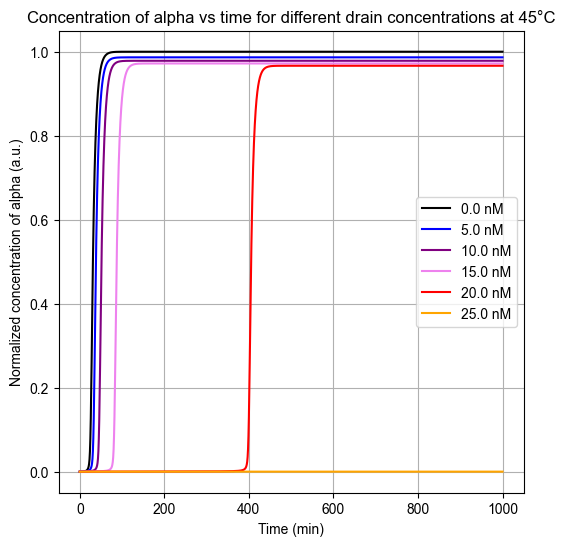

In [3]:
drain_concentrations = np.linspace(0,25,6)

t = np.linspace(0, 1000, 1001)
plt.figure(figsize=(6, 6))

colors=['black','blue', 'purple', 'violet', 'red', 'orange']

max_alpha_concentration=0

for drain_concentration, color in zip(drain_concentrations, colors):
    syst = create_system(alpha_concentration=0, 
                    template_concentration=50, 
                    template_moins=1,
                    drain_concentration=drain_concentration, 
                    drain_sequence="AAAACTCGTCAGAATG",
                    drain_plus=None,
                    temperature=45,
                    leak=6.3e-7, 
                    )
    y=syst.solve_system(t)
    alpha_concentrations=syst.concentration_list(y,"alpha", option="alone") # extract the solution corresponding to alpha

    if drain_concentration==0:
        max_alpha_concentration = max(alpha_concentrations)
    
    plt.plot(
        t,
        alpha_concentrations / max_alpha_concentration,
        label=f'{drain_concentration} nM',
        color=color
    )
    syst.unmalloc()

    
plt.xlabel('Time (min)')
plt.ylabel('Normalized concentration of alpha (a.u.)')
plt.legend()
plt.title(f"Concentration of alpha vs time for different drain concentrations at 45°C")
if saving:
    plt.savefig('figures/drains/Sim_fig3a1.pdf')
plt.grid()
plt.show()


By adjusting the leak rate to 6.3e-7, we get the same results than in the article

### Plot of Fig 3a2

We now plot 1/Ct with respect to the drain concentration, in the same system than previously. Ct is the time at which alpha reach 20% of its maximum value.

In [4]:
import matplotlib.font_manager as fm

[f.name for f in fm.fontManager.ttflist if 'Arial' in f.name]

['Arial',
 'Arial',
 'Arial Black',
 'Arial Black',
 'Arial',
 'Arial',
 'Arial',
 'Arial',
 'Arial',
 'Arial']

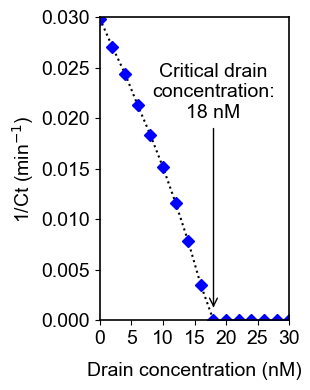

In [5]:
t = np.linspace(0, 5000, 10001)
Ct_inv=[]
drain_concentrations=np.linspace(0, 30, 16)
critical=0

for drain_concentration in drain_concentrations:
    syst = create_system(alpha_concentration=0, 
                    template_concentration=50, 
                    template_moins=1,
                    drain_concentration=drain_concentration, 
                    drain_sequence="AAAACTCGTCAGAATG",
                    drain_plus=None,
                    temperature=45,
                    leak=2e-7, 
                    )
    y=syst.solve_system(t)
    Ct = compute_Ct(syst,y,t)
    if Ct ==0:
        Ct_inv.append(0)
        if not critical:
            critical=drain_concentration
    else:
        Ct_inv.append(1/Ct)
    syst.unmalloc()

plt.figure(figsize=(3.2, 4))
plt.plot(
    drain_concentrations,
    Ct_inv,
    marker='D',  # Diamond marker
    color='black',
    linestyle=':',  # Dotted line
    markerfacecolor='blue',  
    markeredgecolor='blue', 
)

plt.annotate(
    f'Critical drain\nconcentration:\n{int(critical)} nM',
    xy=(critical, 0.001),  # Point where the arrow ends (on the curve)
    xytext=(critical, 0.02),  # Point where the text is placed 
    arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle='angle,angleA=90,angleB=0,rad=0'),
    fontsize=14,
    ha='center',  # Center the text horizontally
)
# Customize y-axis formatting
# ax = plt.gca()
# ax.yaxis.set_major_formatter(
#     ticker.FuncFormatter(lambda x, _: f'{x * 1e3:.1f}')
# )
# # ax.yaxis.offsetText.set_text(r"")
# # ax.yaxis.offsetText.set_visible(True)



plt.xlabel('Drain concentration (nM)', fontsize=14, labelpad=10)
# plt.ylabel(r'1/Ct ($\times 10^{-3}$ min$^{-1}$)')
plt.ylabel(r'1/Ct (min$^{-1}$)', fontsize=14)
plt.xlim(0, 30)
plt.ylim(0, 0.03)

# Remove top and right spines for a clean look
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks([0,5,10,15,20,25,30],fontsize=14)
plt.yticks(fontsize=14)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

plt.tight_layout()
if saving:
    plt.savefig('figures/drains/Sim_fig3a2.pdf')
plt.show()

We have qualitatively the expected result, as all results depend on the choice of the leak rate.
There exist a critical drain template concentration above the one the system reaches bistability.

We can detect this critical value by plotting 1/Ct wrt. the drain concentration. The dependency is linear, as described in the article.

### Check: Plot of the stable equilibrium points

Now, we know that there is a critical drain concentration. However, we would like to investigate that is correctly lead to a bistable point.
Therefore, we will plot the evolution of the equilibrium state depending on the drain concentration, as done in the theoretical plot of Fig 2d in the article.

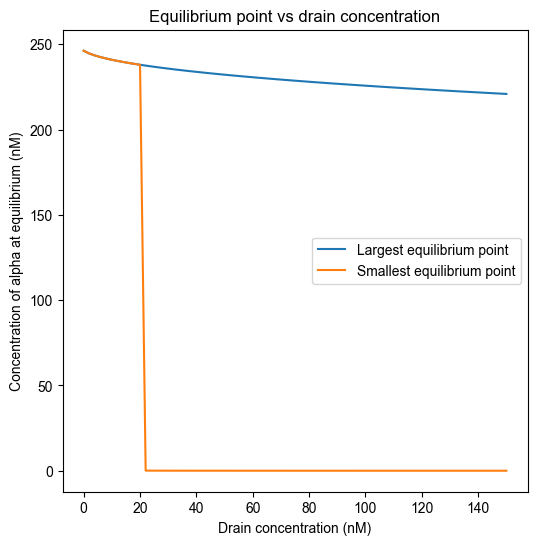

In [6]:
## Plot of the equilibrium point evolution.

t = np.linspace(0, 5000, 10001)
final_conc_from_much = []
final_conc_from_0 = []
drain_concs = np.linspace(0, 150, 76)


for drain_concentration in drain_concs:
    syst = create_system(alpha_concentration=100, 
                    template_concentration=50, 
                    template_moins=1,
                    drain_concentration=drain_concentration, 
                    drain_sequence="AAAACTCGTCAGAATG",
                    drain_plus=None,
                    temperature=45,
                    leak=6.3e-7, 
                    )
    y = syst.solve_system(t)
    alpha_concentrations=syst.concentration_list(y,"alpha")
    final_conc_from_much.append(alpha_concentrations[-1])
    syst.unmalloc()

    syst = create_system(alpha_concentration=0, 
                    template_concentration=50, 
                    template_moins=1,
                    drain_concentration=drain_concentration, 
                    drain_sequence="AAAACTCGTCAGAATG",
                    drain_plus=None,
                    temperature=45,
                    leak=6.3e-7, 
                    )
    y = syst.solve_system(t)
    alpha_concentrations=syst.concentration_list(y,"alpha")
    final_conc_from_0.append(alpha_concentrations[-1])
    syst.unmalloc()


plt.figure(figsize=(6, 6))
plt.plot(drain_concs, final_conc_from_much, label='Largest equilibrium point')
plt.plot(drain_concs, final_conc_from_0, label='Smallest equilibrium point')
plt.xlabel('Drain concentration (nM)')
plt.ylabel('Concentration of alpha at equilibrium (nM)')
plt.title('Equilibrium point vs drain concentration')
plt.legend()
plt.show()


## Plot of Fig 3b

We now to plot figure 3b: the evolution of 1/Ct for differrent drain template sequences. The goal is to analyze the impact of the drain template length.


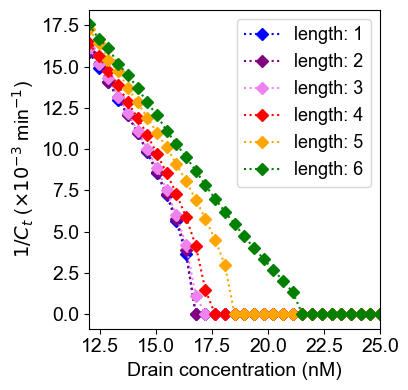

In [7]:
# Plot of fig 3b: 1/Ct vs Drain concentration for different drains
t = np.linspace(0, 1000, 1001)
drain_concentrations=np.linspace(12, 25, 31)
colors=['blue', 'purple', 'violet', 'red', 'orange', 'green']

plt.figure(figsize=(4, 4))


for drain_plus, color in zip(list(range(1,8)), colors):
    Ct_inv=[]
    for drain_concentration in drain_concentrations:
        syst = create_system(alpha_concentration=0, 
                        template_concentration=50, 
                        template_moins=1,
                        drain_concentration=drain_concentration, 
                        drain_sequence=None,
                        drain_plus=drain_plus,
                        temperature=45,
                        leak=6.3e-7, 
                        )
        y=syst.solve_system(t)
        Ct = compute_Ct(syst,y,t)
        if Ct ==0:
            Ct_inv.append(0)
        else:
            Ct_inv.append(1/Ct)
    plt.plot(
    drain_concentrations,
    Ct_inv,
    marker='D',  # Diamond marker
    color=color,
    linestyle=':',  # Dotted line
    markerfacecolor=color,  # Red marker fill
    markeredgecolor=color,  # Black marker edge
    label=f"length: {drain_plus}",
)
 
# Customize y-axis formatting
ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x * 1e3:.1f}')
)
# ax.yaxis.offsetText.set_text(r"")
# ax.yaxis.offsetText.set_visible(True)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('Drain concentration (nM)', fontsize=14)
plt.ylabel(r'$1/C_t$ ($\times 10^{-3}$ min$^{-1}$)', fontsize=14)
plt.xlim(12,25)
# plt.title('1/Ct vs Drain concentration')
plt.legend(fontsize=13)
# plt.grid
plt.tight_layout()
if saving:
    plt.savefig('figures/drains/Sim_fig3b.pdf')
plt.show()

According to the article, the shorter the drain template, the faster the unbinding, the better the degradation of alpha.
Indeed, if the drain template is long, the inactivated strand alpha' slowly dehybridizes, leading to a less efficient inactivation.

However, in the experiments, cases of short drain templates (1 and 2 additional bases) are special. Their critical drain template concentration is higher than theoretically expected, as one or two additional bases may be not enough for completely deactivating the polymerase action, hence the conversion.
In our simulation, we obtain the same results than the theoretic ones.

In the next figure, we simulate for even longer drain template (not experimented in the article). 
The case with 7 'T' in no more linear, as the inactivated strand alpha' (19 nt) almost never unbind from the drain template, at the working temperature.

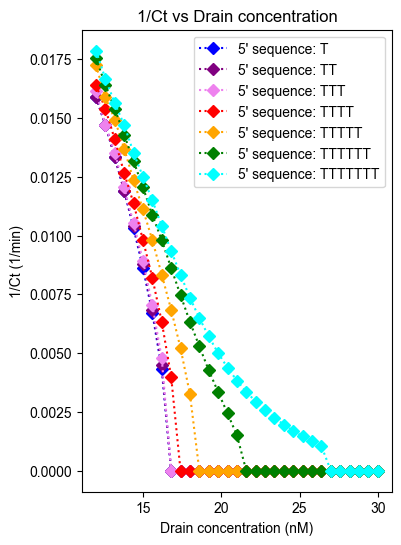

In [8]:
# Plot of fig 3b: 1/Ct vs Drain concentration for different drains

t = np.linspace(0, 1000, 1001)
drain_concentrations=np.linspace(12, 30, 31)
colors=['blue', 'purple', 'violet', 'red', 'orange', 'green', 'cyan']

plt.figure(figsize=(4, 6))


for drain_plus, color in zip(list(range(1,9)), colors):
    Ct_inv=[]
    for drain_concentration in drain_concentrations:
        syst = create_system(alpha_concentration=0, 
                        template_concentration=50, 
                        template_moins=1,
                        drain_concentration=drain_concentration, 
                        drain_sequence=None,
                        drain_plus=drain_plus,
                        temperature=45,
                        leak=6.3e-7, 
                        )
        y=syst.solve_system(t)
        Ct = compute_Ct(syst,y,t)
        if Ct ==0:
            Ct_inv.append(0)
        else:
            Ct_inv.append(1/Ct)
    plt.plot(
    drain_concentrations,
    Ct_inv,
    marker='D',  # Diamond marker
    color=color,
    linestyle=':',  # Dotted line
    markerfacecolor=color,  # Red marker fill
    markeredgecolor=color,  # Black marker edge
    label=f"5' sequence: {drain_plus*'T'}",
)
 
plt.xlabel('Drain concentration (nM)')
plt.ylabel('1/Ct (1/min)')
plt.title('1/Ct vs Drain concentration')
plt.legend()
plt.grid
if saving:
    plt.savefig('figures/drains/Sim_fig3b_bonus.pdf')
plt.show()

## Plot of fig 3c

We plot the same than Fig 3c: the concentration of alpha vs time for different drain concentrations and different template sequences. The goal is to analyze the dependence on the template sequence.

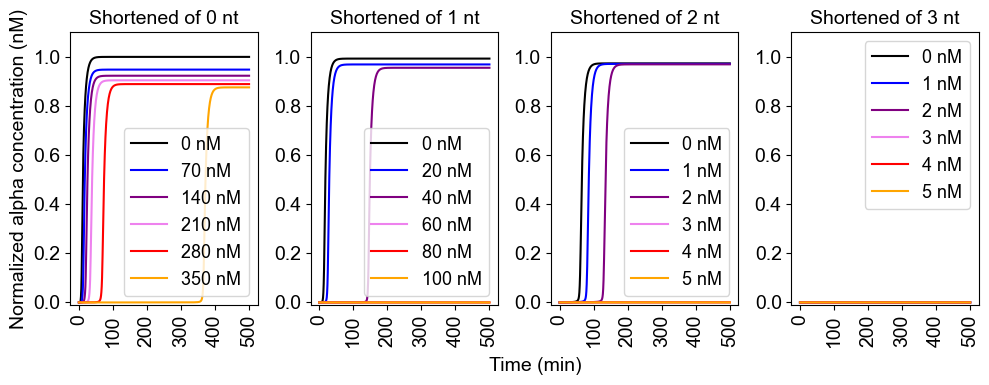

In [9]:
t = np.linspace(0, 500, 1001)

template_moins_list = [0,1,2,3]

drain_concentrations_list = [
    np.linspace(0, 350, 6),
    np.linspace(0, 100, 6),
    np.linspace(0, 5, 6),
    np.linspace(0, 5, 6)
]

colors=['black','blue', 'purple', 'violet', 'red', 'orange']

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 4), sharey=False)
max_alpha_concentration=0

for template_moins, concentration_range, ax in zip(template_moins_list, drain_concentrations_list, axes.flatten()):
    for drain_concentration, color in zip(concentration_range, colors):
        # print(template_moins, drain_concentration)
        syst = create_system(alpha_concentration=0, 
                        template_concentration=50, 
                        template_moins=template_moins,
                        drain_concentration=drain_concentration, 
                        drain_sequence="AAAACTCGTCAGAATG",
                        drain_plus=None,
                        temperature=43,
                        leak=6.3e-7, 
                        )
        # syst.print(detailed_kinetics=True, enzymes_kinetic=True)
        y=syst.solve_system(t)
        alpha_concentrations=syst.concentration_list(y,"alpha")
        if drain_concentration == 0 and template_moins == 0:
            max_alpha_concentration=max(alpha_concentrations)
        ax.plot(
                t,
                alpha_concentrations / max_alpha_concentration,
                color=color,
                label=f'{int(drain_concentration)} nM',
                linewidth=1.5
            )
        syst.unmalloc()
        
    ax.set_title(f"Shortened of {template_moins} nt", fontsize=14)
    # ax.set_xlabel('Time (min)')
    ax.set_ylim(-0.01, 1.1)
    ax.set_xticks([0,100,200,300,400,500])
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.tick_params(axis='x', rotation=90) 
    if template_moins==0:
        ax.set_ylabel('Normalized alpha concentration (nM)', fontsize=14)
    ax.legend(fontsize=13)
# plt.suptitle(f'Concentration of alpha vs time for different drain concentrations (at 43°C)', fontsize=16)
fig.supxlabel('Time (min)', fontsize=14, y=0.050, x=0.54)
plt.tight_layout()
if saving:
    plt.savefig('figures/drains/Sim_fig3c.pdf')
plt.show()

    


We adjusted the simulation temperature from 45°C to 43°C to achieve more appropriate enzymatic rates, as these rates were calibrated at even lower temperatures.

Qualitatively, the simulation reproduces the same behavior as described in the article: the smaller the converter template, the higher the critical drain template concentration.

Quantitatively, however, the results do not perfectly align with those in the article. Specifically, the template reduced by 3 nucleotides (nt) fails to initiate, even at 43°C. This discrepancy may stem from computational errors in the calculation of kinetic rates, particularly since the enzymatic rates in our model do not account for temperature dependence. At higher temperatures, the input template dissociates faster than the polymerase can act, preventing the amplification of alpha—even when the drain template concentration ([dT]) is set to 0 nM.

## Figure 5

45


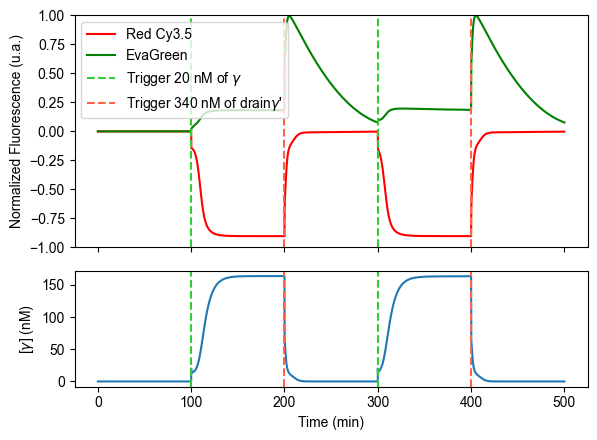

In [10]:
if 1: 
      # Create a signal
      gamma = Signal(name="gamma", 
            sequence="CATTCAGGATCG", 
            concentration=0, 
            protected=False, 
            IsDrained=True
            )
    

    # Create a drain
      drain = Drain(name="drain_gamma", 
            input=gamma, 
            concentration=10, 
            sequence="TTTTTCGATCCTGAATG", 
            protected=True)
    
      drain_nonprot=Drain(name="drain_gamma_prim",
                  input=gamma,
                  sequence="AACGATCCTGAATGA",
                  protected=False
            )
    

    # Create a template
      template = Template(name="aT_gamma", 
                  sequence="CGATCCTGAATGCGATCCTGAA",
                  input=gamma, 
                  output=gamma, 
                  concentration=25, 
                  nick="BsmI", 
                  protected=True, 
                  irreversible=False,
                  phosphorylated=True
                  )
    
    # Create a system
      system = PEN_System(temperature=45) # Adjusted
      system.add_signal(gamma)
      system.add_drain(drain)
      system.add_drain(drain_nonprot)
      system.add_template(template)

      # Enzymes concentration of the article
      system.concentration_pol=8
      system.concentration_BsmI=400
      system.concentration_exo=25

      # Add a leak rate for the polymerase
      system.leak=6.3e-7


system.update_dicts()
system.update_dict_index()
gamma_index=system.dict_index[(gamma, "alone")]
drain_nonprot_index=system.dict_index[(drain_nonprot, "alone")]


# Time segments
t1 = np.linspace(0, 100, 501)
t_segments = [t1]
for i in range(1, 5):
    t_segments.append(100 + t_segments[-1])

# store results
y_results = []
gamma_concentrations = []
alone_templates = []

# Initial conditions
y0 = None
# Solve the system for each time segment
for i, t in enumerate(t_segments):
    y = system.solve_system(t, y0=y0)
    y_results.append(y)
    gamma_concentrations.append(system.concentration_list(y, "gamma"))
    alone_templates.append(system.concentration_list(y, "aT_gamma", "alone"))


    # Update initial condition for the next segment
    y0 = y[-1].copy()

    # Apply perturbations at the end of each segment
    if i == 0 or i == 2:  # After t1 and t3
        y0[gamma_index] += 20
    elif i == 1 or i == 3:  # After t2 and t4
        y0[drain_nonprot_index] += 340


# Create a figure with two subplots
height_ratios = [2,1]  # ax1 is twice as tall as ax2

# Create the figure with specified height ratios
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(6, 4.5),
    sharex=True,
    gridspec_kw={'height_ratios': height_ratios}
)

# --- First subplot: Gamma Concentration ---
t_concat = np.concatenate(t_segments)
gamma_concat = np.concatenate(gamma_concentrations)
ax2.plot(t_concat, gamma_concat)

# Add vertical lines for triggers in the first subplot
for i in range(1, 5):
    x_pos = t_segments[i-1][-1]
    if i % 2 == 1:
        label = r"Trigger 20 nM of $\gamma$"
        color = "limegreen"
    else:
        label = r"Trigger 340 nM of drain$\gamma$'"
        color = "tomato"
    if i <= 2:
        ax2.axvline(x=x_pos, linestyle='--', label=label, color=color)
    else:
        ax2.axvline(x=x_pos, color=color, linestyle='--')

# ax1.set_xlabel("Time (min)")
ax2.set_ylabel(r"[$\gamma$] (nM)")
# ax1.set_title("Gamma Concentration Over Time")

# ax1.legend()

# --- Second subplot: Evagreen and Normalized Gamma ---
y = np.concatenate(y_results)
t_concat = np.concatenate(t_segments)
gamma_concat = np.concatenate(alone_templates)
eva = system.concentration_list(y, "Evagreen")

ax1.plot(t_concat, (gamma_concat - gamma_concat[0]) / (gamma_concat.max() ), color="red", label="Red Cy3.5")
ax1.plot(t_concat, eva - eva[0], color="green", label="EvaGreen")

# Add vertical lines for triggers in the second subplot
for i in range(1, 5):
    x_pos = t_segments[i-1][-1]
    if i % 2 == 1:
        label = r"Trigger 20 nM of $\gamma$"
        color = "limegreen"
    else:
        label = r"Trigger 340 nM of drain$\gamma$'"
        color = "tomato"
    if i <= 2:
        ax1.axvline(x=x_pos, linestyle='--', label=label, color=color)
    else:
        ax1.axvline(x=x_pos, color=color, linestyle='--')

ax2.set_xlabel("Time (min)")
ax1.set_ylabel("Normalized Fluorescence (u.a.)")
ax1.set_ylim(-1,1)
ax1.legend()
# ax2.set_title("Normalized Fluorescence (u.a.) Over Time")

# Adjust layout to prevent overlap
print(system.temperature)
system.unmalloc()
# plt.suptitle("Turning a bistable system on and off")
plt.tight_layout()
if saving:
    plt.savefig('figures/drains/Sim_fig5.pdf')
plt.show()


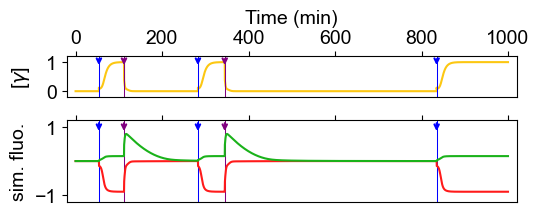

In [11]:
# Create a signal
gamma = Signal(name="gamma", 
    sequence="CATTCAGGATCG", 
    concentration=0, 
    protected=False, 
    IsDrained=True
    )


# Create a drain
drain = Drain(name="drain_gamma", 
    input=gamma, 
    concentration=10, 
    sequence="TTTTTCGATCCTGAATG", 
    protected=True)

drain_nonprot=Drain(name="drain_gamma_prim",
            input=gamma,
            sequence="AACGATCCTGAATGA",
            protected=False
    )


# Create a template
template = Template(name="aT_gamma", 
            sequence="CGATCCTGAATGCGATCCTGAA",
            input=gamma, 
            output=gamma, 
            concentration=25, 
            nick="BsmI", 
            protected=True, 
            irreversible=False,
            phosphorylated=True
            )

# Create a system
system = PEN_System(temperature=45) # Adjusted
system.add_signal(gamma)
system.add_drain(drain)
system.add_drain(drain_nonprot)
system.add_template(template)

# Enzymes concentration of the article
system.concentration_pol=8
system.concentration_BsmI=400
system.concentration_exo=25

# Add a leak rate for the polymerase
system.leak=6.3e-7


system.update_dicts()
system.update_dict_index()
gamma_index=system.dict_index[(gamma, "alone")]
drain_nonprot_index=system.dict_index[(drain_nonprot, "alone")]


# Time segments
t1 = np.linspace(0, 54, 54*10)
t2 = np.linspace(54, 112, (112-54)*10)
t3 = np.linspace(112, 283, (283-112)*10)
t4 = np.linspace(283, 345, (345-283)*10)
t5 = np.linspace(345, 835, (835-345)*10)
t6 = np.linspace(835, 1000, (1000-835)*10)
t_segments = [t1, t2, t3, t4, t5, t6]

# store results
y_results = []
gamma_concentrations = []
alone_templates = []

# Initial conditions
y0 = None
# Solve the system for each time segment
for i, t in enumerate(t_segments):
    y = system.solve_system(t, y0=y0)
    y_results.append(y)
    gamma_concentrations.append(system.concentration_list(y, "gamma"))
    alone_templates.append(system.concentration_list(y, "aT_gamma", "alone"))


    # Update initial condition for the next segment
    y0 = y[-1].copy()

    # Apply perturbations at the end of each segment
    if i%2 == 0:  # After t1 and t3
        y0[gamma_index] += 20
    else : # After t2 and t4
        y0[drain_nonprot_index] += 340


# Create a figure with two subplots

# Create a figure with two subplots
height_ratios = [1,2]  # ax1 is twice as tall as ax2

# Create the figure with specified height ratios
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(5.5, 2.25),
    sharex=True,
    gridspec_kw={'height_ratios': height_ratios}
)

# --- First subplot: Gamma Concentration ---
t_concat = np.concatenate(t_segments)
gamma_concat = np.concatenate(gamma_concentrations)
ax1.plot(t_concat, gamma_concat/gamma_concat.max(), color="#fcc712", linewidth=1.5)

# Add vertical lines and arrows for triggers in the first subplot
for i in range(1, 6):
    x_pos = t_segments[i][0]
    if i % 2 == 1:  # Switch-on (20 nM of gamma)
        color = "blue"
        ax1.annotate('',
                    xy=(x_pos, 0.8),  # Starting point of the arrow (on the plot)
                    xytext=(x_pos, 1.2),  # Ending point of the arrow (above the plot)
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.5),  # Thicker arrow with `lw=2`
                    color=color, fontsize=8)
        ax2.annotate('',
                    xy=(x_pos, 0.8),  # Starting point of the arrow (on the plot)
                    xytext=(x_pos, 1.2),  # Ending point of the arrow (above the plot)
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.5),  # Thicker arrow with `lw=2`
                    color=color, fontsize=8)
    else:  # Switch-off (340 nM of drain)
        color = "purple"
        ax1.annotate('',
                    xy=(x_pos, 0.8),  # Starting point of the arrow (on the plot)
                    xytext=(x_pos, 1.2),  # Ending point of the arrow (above the plot)
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.5),  # Thicker arrow with `lw=2`
                    color=color,
                    fontsize=8)
        ax2.annotate('',
                    xy=(x_pos, 0.8),  # Starting point of the arrow (on the plot)
                    xytext=(x_pos, 1.2),  # Ending point of the arrow (above the plot)
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.5),  # Thicker arrow with `lw=2`
                    color=color,
                    fontsize=8)


    ax2.axvline(x=x_pos, color=color, linewidth=0.75)
    ax1.axvline(x=x_pos, color=color, linewidth=0.75)

ax1.tick_params(axis='both', which='major', labelsize=14)
ax2.tick_params(axis='both', which='major', labelsize=14)
# ax1.xaxis.label.set_size(20)
# ax.yaxis.label.set_size(10)

ax1.set_ylabel(r"[$\gamma$]", fontsize=14, labelpad=10)
ax2.set_ylabel(r"sim. fluo.", fontsize=14, labelpad=5)

# --- Second subplot: Evagreen and Normalized Gamma ---
y = np.concatenate(y_results)
t_concat = np.concatenate(t_segments)
gamma_concat = np.concatenate(alone_templates)
eva = system.concentration_list(y, "Evagreen")

ax2.plot(t_concat, (gamma_concat - gamma_concat[0]) / gamma_concat.max(), color="#ff1a1a", label="Red Cy3.5", linewidth=1.5)
ax2.plot(t_concat, 0.8*(eva - eva[0]), color="#1ab21a", label="EvaGreen", linewidth=1.5)

ax2.set_ylim(-1.2, 1.2)
ax1.set_ylim(-0.2, 1.2)
ax2.set_xlim(-20, 1000+20)

# --- Set x-axis ticks and label at the top ---
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position('top')
ax1.set_xlabel("Time (min)", fontsize=14)
ax1.set_xticks([0, 200, 400, 600, 800, 1000])
ax2.set_yticks([-1,1])
ax1.set_yticks([0,1])





# --- Ensure ticks and labels are only on top ---
ax1.tick_params(axis='x', bottom=False, top=True, labeltop=True, labelbottom=False)
ax2.tick_params(axis='x', bottom=False, top=True, labeltop=False, labelbottom=False)


# Adjust layout to prevent overlap
plt.tight_layout()

# Save the figure
if saving:
    plt.savefig('figures/drains/Sim_fig5.pdf', dpi=300, bbox_inches='tight')

    

plt.show()


We simulate a triggering of 340 nM of $\text{drain}\gamma$' instead of 60 nM.
The EvaGreen fluorescence represents the amount of doubled-stranded DNA, whereas the redCy3.5 fluorescence (used in the article) reveal the amount of aT in the alone configuration.

The behavior of the system is coherent with the figure  5 of the article: we can switch the bistable on and off in a row. Moreover, the fluorescence curves have the same shape.

# Conclusion

The simulation **qualitatively reproduces** all the selected results from the article. They are the bistability of a system, and the effects of the sequences of the converter and drain templates. 

It confirms that the new method for computing hybridization rates, based on sequence-specific interactions, **successfully captures the experimentally observed behaviors**.

However, when examining the quantitative results, several uncertainties persist. The first unknown parameter is the polymerase leak rate, which was arbitrarily set to 6.3e-7 in this study. To our knowledge, the mechanism underlying polymerase leaks remains poorly understood.
Additionally, the temperature dependence of enzymatic rates could be further refined to enable more quantitatively precise simulations.
